<a href="https://colab.research.google.com/github/claramanolache/ML_Intro/blob/main/Week_6_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Instructions

For this assignment, you will use the Penguins dataset to compare Support Vector Machine (SVM) and Decision Tree classifiers. Complete all code cells following the provided instructions.

**Do not delete any instructor-provided cells from this Notebook.** If you accidentally delete a cell, you can either undo the action or load a copy of the original assignment Notebook in a new browser tab and copy over the missing cells.

**You can add cells to this Notebook.** To add a markdown (text) cell, hover your cursor beneath the cell where you want to insert and click the "+Text" button. To add a Python (code) cell, click the "+Code" button.

### Steps
- Load and explore the Penguins dataset.
- Prepare the data by removing null values and splitting into training and test sets.
- Build SVM and Decision Tree classifiers to predict categorical features using only numerical features.
- Experiment with regularization hyperparameters for both models.
- Compare model performance and report findings about which classifier performed best for different prediction tasks.

## Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import svm
from sklearn import tree

The following variable will be used to set a random seed for certain processes. Using a seed makes random processes deterministic, meaning this notebook will do things like split data the same way on each run.

You are free to change this value to explore how the notebook runs differently.

In [ ]:
seed = 42

## Load the Dataset

The Penguins dataset was collected by the Palmer Station, Antarctica Long-Term Ecological Research program. It comprises measurements from three penguin species - Adelie, Gentoo, and Chinstrap - living on islands in the Palmer Archipelago, Antarctica.

### Features
- **bill_length_mm**: Length of the penguin's bill in millimeters.
- **bill_depth_mm**: Depth of the penguin's bill in millimeters.
- **flipper_length_mm**: Length of the penguin's flipper in millimeters.
- **body_mass_g**: Body mass of the penguin in grams.

### Categorical Variables
- **species**: The species of penguin (Adelie, Gentoo, Chinstrap).
- **island**: The island where the penguin was observed (Torgersen, Biscoe, Dream).
- **sex**: The sex of the penguin (Male, Female).
  - Note: This column will not be used for this assignment.

In [ ]:
df = sns.load_dataset("penguins").drop(columns="sex")
df.shape

(344, 6)

### Inspect the Data

Display the first few rows and check for missing values.

In [ ]:
df.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0
3,Adelie,Torgersen,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0


## Prepare the Data

Because we will be using two target vectors for the first time, most of the preparation steps have been completed for you.

### Remove Null Values

In [ ]:
df.isnull().sum()
df = df.dropna(ignore_index=True)
df.shape

(342, 6)

### Create a Feature Matrix

The feature matrix `X` should only contain numerical features.

In [ ]:
X = df.drop(columns=["island", "species"])
X.shape

(342, 4)

### Create Two Target Vectors

Later, you will perform two classification tasks with these targets.

In [ ]:
y_island = df["island"]
y_species = df["species"]
y_island.shape, y_species.shape

((342,), (342,))

### Split into Training and Test Sets

Split the data into training and test sets.

It is worth noting that `train_test_split` can take multiple matrices and vectors (that have the same number of samples) and will split each appropriately. When splitting many such objects, pay attention to the order that you pass them in to the split function, as that determines the order that they will be returned.

In [ ]:
test_size=0.2

In [ ]:
X_train, X_test, y_island_train, y_island_test, y_species_train, y_species_test = model_selection.train_test_split(
    X, y_island, y_species, test_size=test_size, random_state=seed
)
X_train.shape, y_island_train.shape, y_species_train.shape, \
  X_test.shape, y_island_test.shape, y_species_test.shape

((273, 4), (273,), (273,), (69, 4), (69,), (69,))

### Scale the Feature Matrix

SVMs require feature scaling. Use StandardScaler to scale the numerical features.

In [ ]:
scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Visualize the Dataset

Create at least one visualization to explore relationships between numerical features. Use color to distinguish categories.

Although the use of Generative AI to write code for all other parts of assignments is discouraged, for visualizations - which are not strictly part of a machine learning curriculum - you may use Gemini or another LLM of your choice to write Matplotlib (or Seaborn) code, which may help you better explore the data.

**However, be sure you understand and explain any visualization that is part of your submission.**

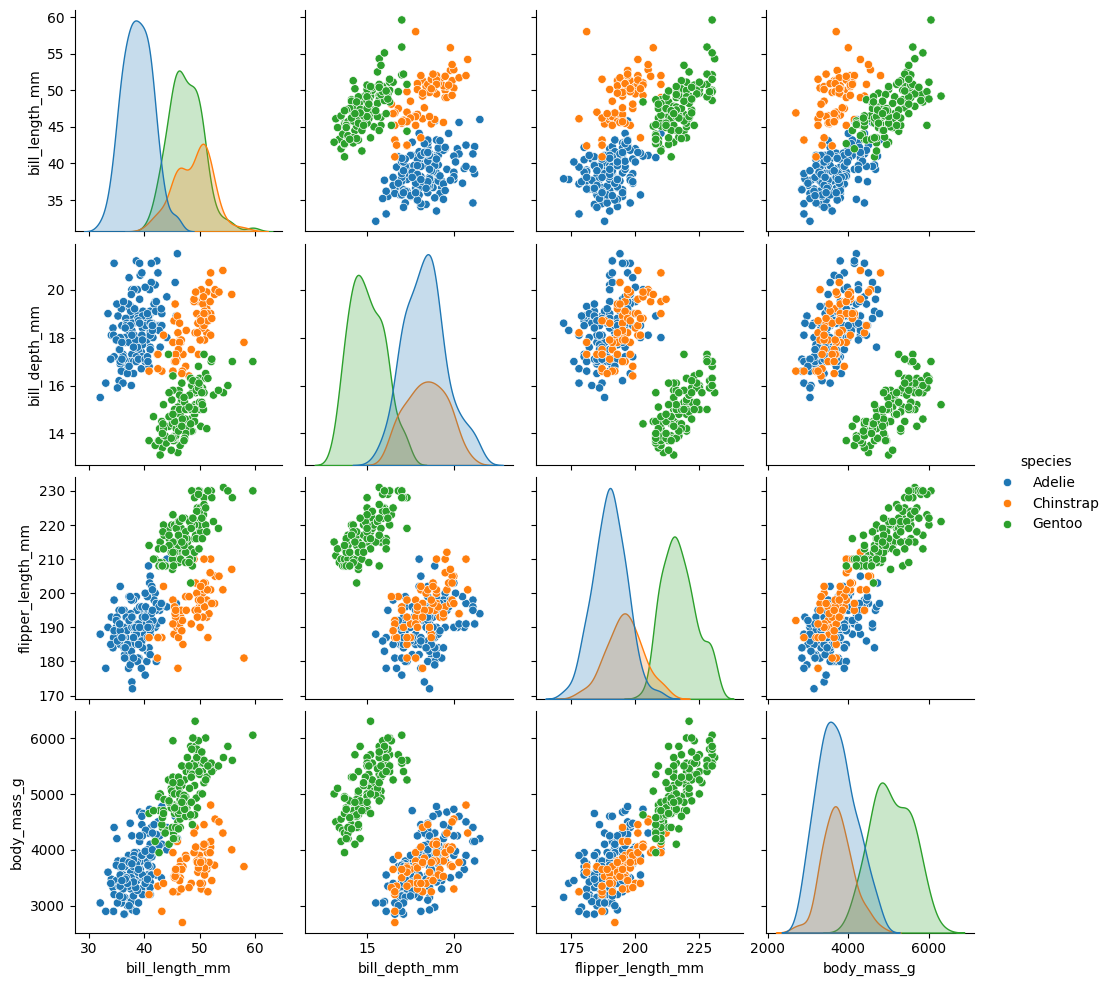

In [ ]:
sns.pairplot(df, hue='species')

### Report Findings

Describe what your visualization(s) represent and what you observe.

My visualization shows that there is often overlap between Chinstrap and Adelie species for body mass, flipper length, and bill depth. These two species have lower body mass and flipper length but deeper bills than the Gentoo species.
However, for bill length, there is overlap between the Gentoo and the Chinstrap. These two have longer bills than the Adelie.


In total, I think that the Gentoo penguins will be the easiest to distinguish, because they have the large size across most features and less overlap with other species.
I also think that the bill length will serve as key distingushing feature between the Adelie and Chinstrap penguins.

Most of the scatterplots show good seperation between the species, so the model should not have too much difficulty using only numerical features.


## Task 1: Predict Penguin Species

Use only the numerical features - `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g` - to predict penguin species.

### Train an SVM Classifier

Train an SVM with an RBF kernel. Experiment with the C and gamma hyperparameters.
- C: Regularization parameter. Lower values create a softer margin.
- gamma: Kernel coefficient. Lower values create a broader decision boundary.

In [ ]:
svc_clf = svm.SVC(kernel="rbf", C=10, gamma="scale")
svc_clf.fit(X_train_scaled, y_species_train)

SVC(C=10)

### Evaluate the SVM

Make predictions on the test set and calculate accuracy.

In [ ]:
svc_pred = svc_clf.predict(X_test_scaled)
accuracy = metrics.accuracy_score(y_species_test, svc_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9855


Display a confusion matrix for the SVM predictions.

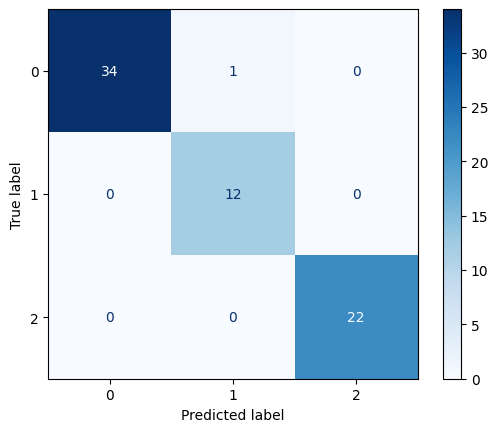

In [ ]:
svc_cm = metrics.confusion_matrix(y_species_test, svc_pred)

disp_cm = metrics.ConfusionMatrixDisplay(confusion_matrix=svc_cm)
disp_cm.plot(cmap=plt.cm.Blues)

### Train a Decision Tree Classifier

Train a Decision Tree using the Gini criterion. Experiment with `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_leaf_nodes` hyperparameters. (Since there are only 4 features, setting `max_features` may not be helpful.)

Note: Decision Trees do not require scaled features; you may use the original (unscaled) numerical features if you want to assess its performance on the original data.

In [ ]:
clf = tree.DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    max_leaf_nodes=None,
    max_features=None,
    random_state=seed
)

clf.fit(X_train, y_species_train)

y_pred = clf.predict(X_test)
print(f"Decision Tree Accuracy: {metrics.accuracy_score(y_species_test, y_pred):.4f}")

Decision Tree Accuracy: 0.9565


### Display the Tree

Use `plot_tree` to display a diagram of the Decision Tree (see the Practice Notebook for an example).

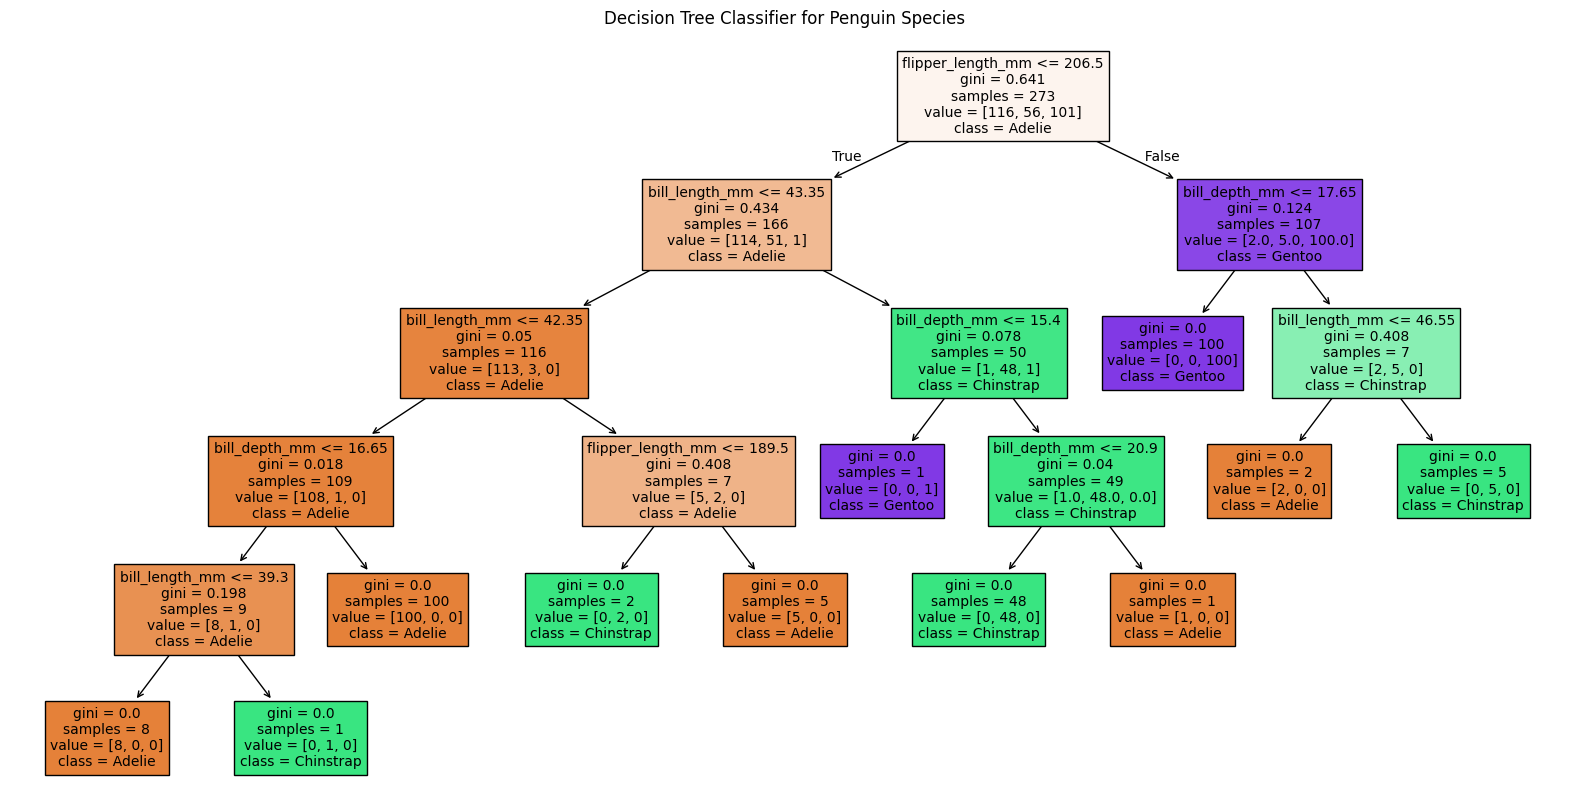

In [ ]:
plt.figure(figsize=(20, 10))
tree.plot_tree(
    clf,
    feature_names=X_train.columns,
    class_names=clf.classes_,
    filled=True,
    fontsize=10
)
plt.title("Decision Tree Classifier for Penguin Species")
plt.show()

### Evaluate the Decision Tree

Make predictions on the test set and calculate accuracy.

In [ ]:
y_pred = clf.predict(X_test)
print(f"Decision Tree Accuracy: {metrics.accuracy_score(y_species_test, y_pred):.4f}")

Decision Tree Accuracy: 0.9565


Display a confusion matrix for the Decision Tree predictions.

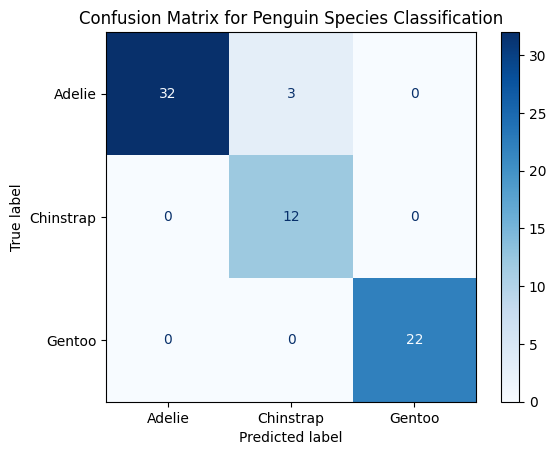

In [ ]:
cm = metrics.confusion_matrix(y_species_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=clf.classes_
)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.show()

### Compare SVM and Decision Tree for Species Prediction

Which model performed better? Why do you think this is the case based on the data and the nature of each algorithm?

The SVM preformed better (98.6% vs 95.6%). I think this is the case because the data was fairly easy to seperate when plotted (as seen in the pairplot generated) but not individually. SVMs are made for seperating clusters, so when the data is easy to seperate, then they thrive. However, the Decision Tree makes linear boundaries within the data, but as seen by the individual plots, the values often overlap. So this type of boundary and approach is not as optimal as the SVM.




### Optimize Decision Tree Hyperparameters for Species Prediction

Let's use `GridSearchCV` to find the best hyperparameters for the Decision Tree classifier when predicting the `species` target.

In [ ]:
param_grid_dt_species = {
    'max_depth': [2, 3, 5, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_leaf_nodes': [None, 10, 20, 50]
}

dt_grid_search_species = model_selection.GridSearchCV(
    tree.DecisionTreeClassifier(criterion="gini", random_state=seed),
    param_grid_dt_species,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1
)

dt_grid_search_species.fit(X_train, y_species_train)

print("Best parameters for Decision Tree (Species Prediction):", dt_grid_search_species.best_params_)
print("Best accuracy for Decision Tree (Species Prediction):", dt_grid_search_species.best_score_)

Fitting 5 folds for each of 320 candidates, totalling 1600 fits
Best parameters for Decision Tree (Species Prediction): {'max_depth': 5, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best accuracy for Decision Tree (Species Prediction): 0.9743434343434343


## Task 2: Predict Penguin Island

Now use the same numerical features to predict which island each penguin is from.

### Train an SVM Classifier

Train an SVM to predict island. Try different values for C and gamma.

In [ ]:
svc_clf_is = svm.SVC(kernel="rbf", C=1, gamma="scale")
svc_clf_is.fit(X_train_scaled, y_island_train)

SVC(C=1)

### Evaluate the SVM

Make predictions on the test set and calculate accuracy.

In [ ]:
y_pred_is = svc_clf_is.predict(X_test_scaled)
accuracy = metrics.accuracy_score(y_island_test, y_pred_is)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6377


Display a confusion matrix for the SVM predictions.

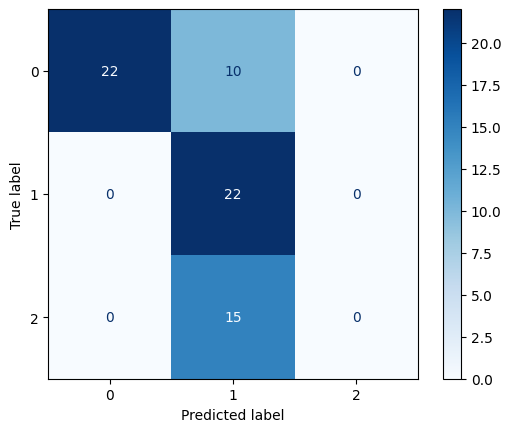

In [ ]:
svc_cm = metrics.confusion_matrix(y_island_test, y_pred_is)

disp_cm = metrics.ConfusionMatrixDisplay(confusion_matrix=svc_cm)
disp_cm.plot(cmap=plt.cm.Blues)

### Optimize SVM Hyperparameters for Island Prediction

Let's use `GridSearchCV` to find the best `C` and `gamma` values for the SVM classifier when predicting the `island` target.

### Train a Decision Tree Classifier

Train a Decision Tree to predict island. Experiment with hyperparameters.

In [ ]:
clf_is = tree.DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=2,
    max_leaf_nodes=10,
    max_features=None,
    random_state=seed
)

clf_is.fit(X_train, y_island_train)

y_pred = clf_is.predict(X_test)
print(f"Decision Tree Accuracy: {metrics.accuracy_score(y_island_test, y_pred):.4f}")

Decision Tree Accuracy: 0.6522


### Display the Tree

Use `plot_tree` to display a diagram of the Decision Tree.

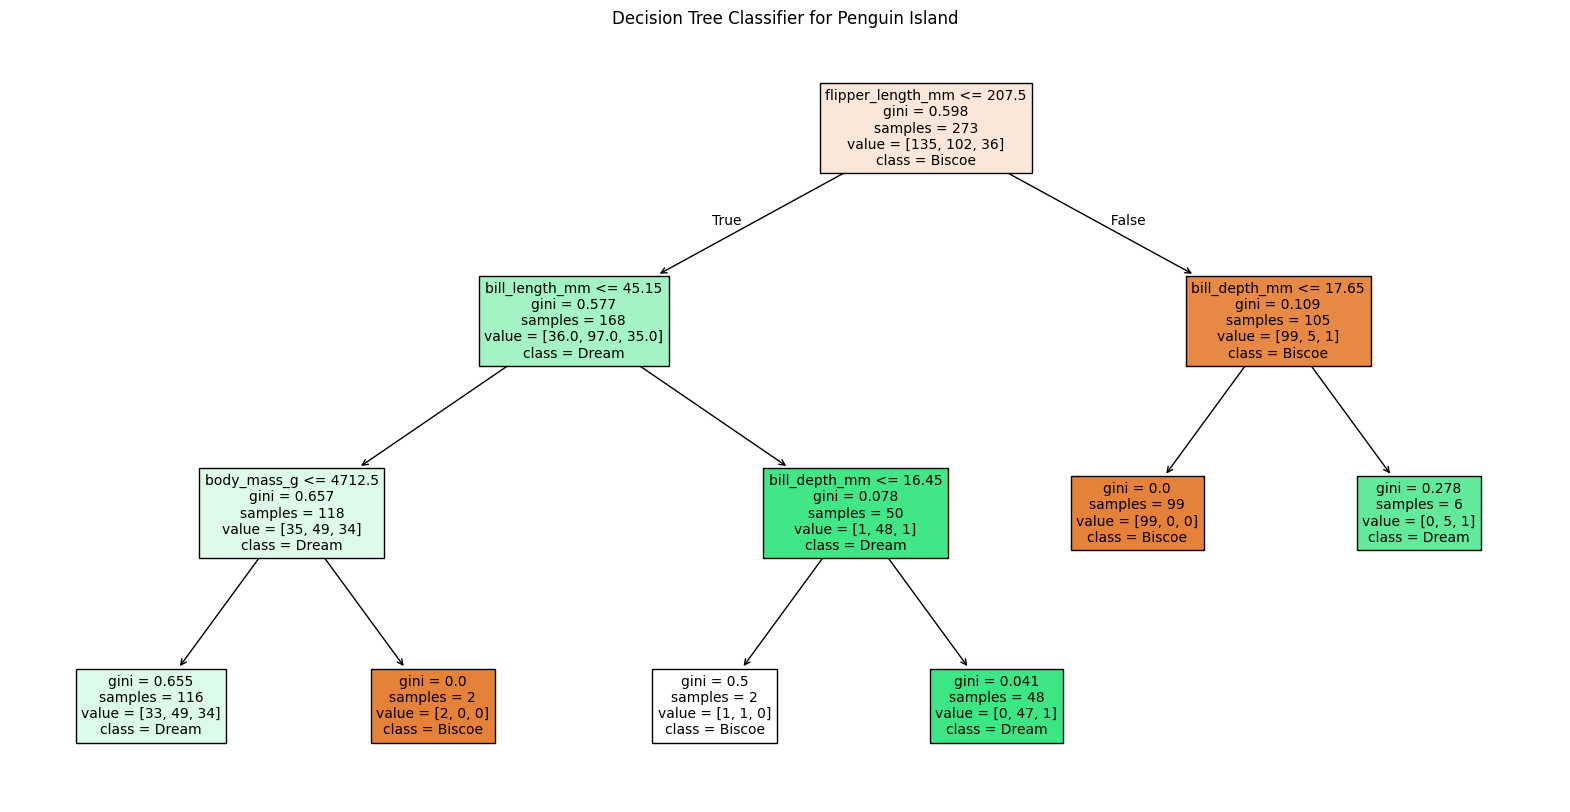

In [ ]:
plt.figure(figsize=(20, 10))
tree.plot_tree(
    clf_is,
    feature_names=X_train.columns,
    class_names=clf_is.classes_,
    filled=True,
    fontsize=10
)
plt.title("Decision Tree Classifier for Penguin Island")
plt.show()

### Evaluate the Decision Tree

Make predictions on the test set and calculate accuracy.

In [ ]:
y_pred = clf_is.predict(X_test)
print(f"Decision Tree Accuracy: {metrics.accuracy_score(y_island_test, y_pred):.4f}")

Decision Tree Accuracy: 0.6522


Display a confusion matrix for the Decision Tree predictions.

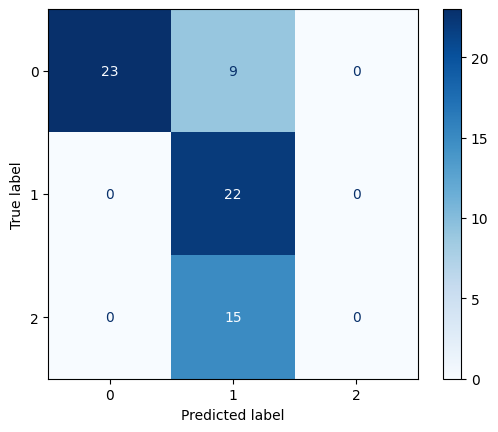

In [ ]:
svc_cm = metrics.confusion_matrix(y_island_test, y_pred)

disp_cm = metrics.ConfusionMatrixDisplay(confusion_matrix=svc_cm)
disp_cm.plot(cmap=plt.cm.Blues)

### Compare SVM and Decision Tree for Island Prediction

Which model performed better? Why do you think this is the case?

The decision tree performed slightly better than the initial SVM, with 65.2% accuracy compared with 63.8%. Because the samle size was so small, that difference is only 1 prediction. However, both models performed much worse on island than on species. This is probably because the data's numerical measurements directly only describe penguin anatomy, which differs substantially by species, but is not a direct indicator of location. Penguins of the same species can live on different islands and have similar measurements, so the classes overlap considerably. The models may therefore be learning indirect relationships between species and island rather than features that uniquely identify each island.

## Experiment with Regularization

Try different hyperparameter values with your SVM and Decision Tree models. Some values you might want to try are listed below; you only need to pick a few that represent a good range of possibilities, based on your previous observations and your understanding of regularization for each model type.

### For SVMs:
- Try C values: 0.1, 1.0, 10.0, 100.0
- Try gamma values: "scale", "auto", 0.001, 0.01, 0.1

### For Decision Trees:
- Try max_depth values: 2, 3, 5, 10, None
- Try min_samples_split values: 2, 5, 10, 20
- Try min_samples_leaf values: 1, 2, 5, 10
- Try max_leaf_nodes values: None, 10, 20, 50

Record the accuracy for a few different combinations and identify which hyperparameters work best for each task in the section below.

### Report Regularization Findings

Summarize which hyperparameters worked best for:
1. SVM predicting species
2. Decision Tree predicting species
3. SVM predicting island
4. Decision Tree predicting island

Briefly explain why you think certain hyperparameters performed better. Your answer need only be based on your current understanding of these models and their hyperparameters, even if that understanding is limited. Thoughtfulness is more important than correctness here.

1. SVM predicting species

* 0.1 preformed worse with scale (95.6) and 10 and 100 did equally good/best with scale (98.6).
* There was no difference with scale and auto on 100 or 10
* .01 and 0.001 both worsened performance (95.7% and 97.1% respectively) and .1 made no difference, so I kept scale


This combination performed best because the higher C allowed the SVM to fit the clearly separated species clusters more closely, while gamma="scale" created an appropriately flexible boundary without overfitting.

2. Decision Tree predicting species
* max_depth value of 2 and 3 decreased accuracy; 5, 10 and None had no difference, so I kept max_depth at None and will ajust again after
* Min_sample_split had no difference at 2 and 5, but decreased at 10 and 20, so I kept it at 5 and will ajust again later
* So far, best performance is 95.7
* Min__sample_leaf has no difference at 1 and 2 or at 5 and 10, but is worse for 5 and 10.
* Right now, configuration is max_depth': 5, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2
* There is no difference between the max_nodes because the tree is so small.

This combination performed best because the tree was deep enough to capture differences between species but still restricted enough to avoid unnecessary complexity and overfitting.

3. SVM predicting island

* C values of 10 and 100 decrease accuracy
* There is no difference between auto and scale for either 0.1 or 1
* .001 decreased accuracy but there is no difference between .01 and .1 or scale or auto, so im keeping it at scale

This combination performed best because the lower C created a softer margin that handled the substantial overlap between island classes better, while gamma="scale" provided a reasonable decision-boundary width.

4. Decision Tree predicting island

* max_depth of 2 decreased accuracy, everything else has same
* I kept max_depth of 3
* There was no difference between any of the min_sample_splits with 3, so I changed to 5 and there was still no difference, and even at None
* Min_sample_leaf decreases at 5 and 10
* max_leaf_nodes has no difference
* So, I kept  max_depth=3, min_samples_split=20,  min_samples_leaf=2, max_leaf_nodes=10 with accuracy of 65.2%

This combination performed best because a shallow tree captured the limited useful patterns in the numerical features while the other restrictions prevented it from fitting noise in the overlapping island data.

## Final Summary

Reflect on the overall comparison between SVMs and Decision Trees on the Penguins dataset.

### Questions to Address:
1. Which classifier (SVM or Decision Tree) performed best for each task? Was there one that performed best overall?
2. Based on your understanding of how SVMs and Decision Trees work, why do you think you observed these results?
3. What role did regularization play in improving model performance, if any?